# PresyoPH – Evaluation and Model Selection (Task 4)

Scores the CPI forecasts from task 3 with MAE, RMSE, and MAPE, and selects the final model.

**What is scored.** Each model forecasts CPI. Inflation and purchasing power are derived from that CPI forecast (option B) and scored against PSA's published series, so every model has metrics for all three variables.

**Evaluations**

| Evaluation | Origins | Forecast months per model |
|---|---|---|
| Main test | Aug 2025 → forecasts Sep 2025 – Aug 2026 | 12 |
| Rolling origin | Aug 2022, Feb 2023, Aug 2023, Feb 2024, Aug 2024 → 12 months each | 60 |
| **Pooled (used for selection)** | all six origins | **72** |

**Selection rule** (applied to CPI): the model with the lowest error on at least 2 of the 3 metrics; otherwise the lowest RMSE. ETS is reported but not eligible, as it is not in the proposal.

**Note on the selection basis.** The rule was first set to use the main 12-month test alone, with rolling origin as a check. After the results were seen, the basis was changed to the pooled six origins, because the main test result depends heavily on the March–April 2026 price shock (sections 2–3). Both results are reported below, and this change must be disclosed in the paper.

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from modeling import config
from modeling import evaluation as ev
from modeling.derive import derive_all
from modeling.temp_loader import load_cpi, load_inflation, load_purchasing_power

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", "{:.3f}".format)

COLORS = {"ARIMA": "tab:blue", "Linear Regression": "tab:orange", "Moving Average": "tab:green", "ETS": "tab:purple"}
MODEL_ORDER = config.PROPOSAL_MODELS + config.EXTRA_MODELS
VARIABLE_LABELS = {"cpi": "CPI", "inflation": "Inflation", "purchasing_power": "Purchasing power"}

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

def wide(metrics):
    """Models as rows; (variable, metric) as columns."""
    table = metrics.pivot(index="model", columns="variable", values=config.METRICS)
    table = table.swaplevel(axis=1)[[v for v in config.VARIABLES]]
    table = table.reindex(columns=config.METRICS, level=1).rename(columns=VARIABLE_LABELS, level=0)
    return table.reindex([m for m in MODEL_ORDER if m in table.index])

cpi = load_cpi()
actuals = {"cpi": cpi, "inflation": load_inflation(), "purchasing_power": load_purchasing_power()}

## 1. Main test: forecasts from Aug 2025

In [2]:
_, main = ev.forecast_from(cpi, config.TRAIN_END)
main = ev.attach_actuals(main, actuals)
main[main["variable"] == "cpi"].pivot(index="date", columns="model", values="forecast").assign(
    actual=actuals["cpi"][config.TEST_START:config.TEST_END])[["actual"] + MODEL_ORDER].round(2)

model,actual,ARIMA,Linear Regression,Moving Average,ETS
date,,,,,
2025-09-01,128.500,129.010,130.250,127.830,128.740
2025-10-01,128.600,129.410,130.630,127.830,128.980
2025-11-01,128.900,129.780,131.000,127.830,129.230
2025-12-01,130.000,130.140,131.380,127.830,129.470
2026-01-01,131.000,130.490,131.750,127.830,129.710
2026-02-01,131.200,130.840,132.130,127.830,129.950
2026-03-01,133.000,131.190,132.500,127.830,130.190
2026-04-01,136.500,131.530,132.880,127.830,130.430
2026-05-01,135.800,131.880,133.250,127.830,130.680


## 2. Main test metrics

Metrics for the full test period and for the months before and after the March–April 2026 price shock. Lower is better. MAE and RMSE are in each variable's own units (index points for CPI and purchasing power in pesos, percentage points for inflation); MAPE is in percent.

*Inflation's MAPE is large for every model because test-period inflation is as low as 1.5%, so a miss of one percentage point is a large percentage error.*

In [3]:
main_metrics = {}
for label, (start, end) in config.TEST_SUBPERIODS.items():
    main_metrics[label] = ev.metrics_table(main, start, end)
    print(label)
    display(wide(main_metrics[label]))

full test (Sep 2025 - Aug 2026)


variable            CPI             Inflation              Purchasing power  \
                    MAE  RMSE  MAPE       MAE  RMSE   MAPE              MAE   
model                                                                         
ARIMA             1.972 2.537 1.463     1.550 1.992 33.493            0.012   
Linear Regression 1.758 1.935 1.321     1.375 1.510 46.298            0.009   
Moving Average    4.750 5.671 3.530     3.708 4.436 85.687            0.025   
ETS               2.671 3.422 1.978     2.092 2.673 43.127            0.016   

variable                       
                   RMSE  MAPE  
model                          
ARIMA             0.015 1.568  
Linear Regression 0.011 1.216  
Moving Average    0.031 3.373  
ETS               0.020 2.136

before shock (Sep 2025 - Feb 2026)


variable            CPI             Inflation              Purchasing power  \
                    MAE  RMSE  MAPE       MAE  RMSE   MAPE              MAE   
model                                                                         
ARIMA             0.535 0.592 0.414     0.417 0.460 23.924            0.005   
Linear Regression 1.490 1.578 1.152     1.183 1.256 68.347            0.008   
Moving Average    1.867 2.169 1.432     1.433 1.666 73.469            0.008   
ETS               0.671 0.798 0.514     0.533 0.630 27.217            0.005   

variable                       
                   RMSE  MAPE  
model                          
ARIMA             0.007 0.647  
Linear Regression 0.011 1.071  
Moving Average    0.012 1.094  
ETS               0.007 0.652

after shock (Mar 2026 - Aug 2026)


variable            CPI             Inflation              Purchasing power  \
                    MAE  RMSE  MAPE       MAE  RMSE   MAPE              MAE   
model                                                                         
ARIMA             3.409 3.539 2.512     2.683 2.780 43.062            0.018   
Linear Regression 2.026 2.235 1.490     1.567 1.727 24.248            0.010   
Moving Average    7.633 7.722 5.628     5.983 6.049 97.904            0.042   
ETS               4.670 4.773 3.442     3.650 3.728 59.038            0.027   

variable                       
                   RMSE  MAPE  
model                          
ARIMA             0.020 2.490  
Linear Regression 0.012 1.361  
Moving Average    0.042 5.652  
ETS               0.028 3.619

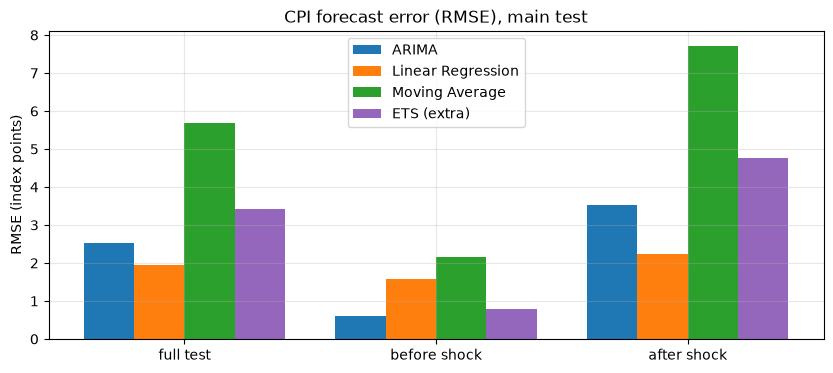

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
labels = list(config.TEST_SUBPERIODS)
x = np.arange(len(labels))
width = 0.2
for i, model in enumerate(MODEL_ORDER):
    values = [main_metrics[l].query("variable == 'cpi' and model == @model")["RMSE"].iloc[0] for l in labels]
    ax.bar(x + (i - 1.5) * width, values, width, color=COLORS[model],
           label=model + (" (extra)" if model in config.EXTRA_MODELS else ""))
ax.set_xticks(x, [l.split(" (")[0] for l in labels])
ax.set_ylabel("RMSE (index points)")
ax.set_title("CPI forecast error (RMSE), main test")
ax.legend()
save(fig, "14_main_test_rmse_by_period")
plt.show()

## 3. Why the main test favours Linear Regression

Mean error (actual − forecast) shows whether a model's forecasts were too high (negative) or too low (positive) on average.

In [5]:
cpi_main = main[main["variable"] == "cpi"]
bias = pd.DataFrame({
    label.split(" (")[0]: cpi_main[(cpi_main["date"] >= start) & (cpi_main["date"] <= end)].groupby("model")["error"].mean()
    for label, (start, end) in config.TEST_SUBPERIODS.items()
}).reindex(MODEL_ORDER)
bias.rename_axis("mean error (actual − forecast), CPI")

,full test,before shock,after shock
"mean error (actual − forecast), CPI",,,
ARIMA,1.583,-0.243,3.409
Linear Regression,0.268,-1.490,2.026
Moving Average,4.750,1.867,7.633
ETS,2.512,0.354,4.670


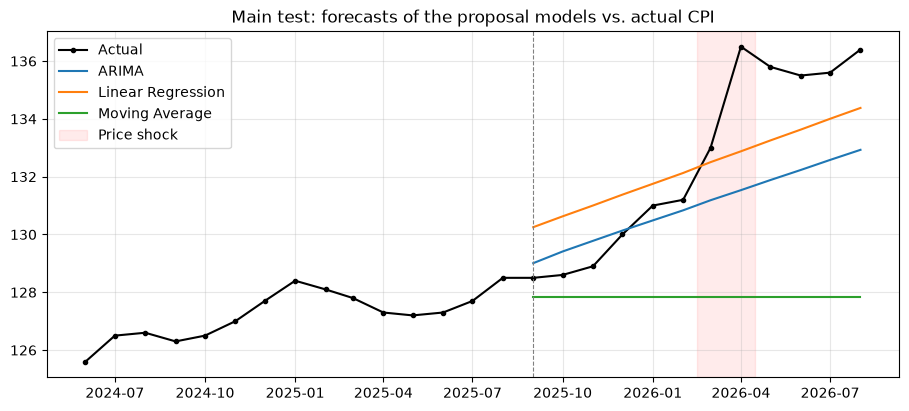

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(cpi["2024-06":], color="black", marker="o", markersize=3, label="Actual")
for model in config.PROPOSAL_MODELS:
    series = cpi_main[cpi_main["model"] == model].set_index("date")["forecast"]
    ax.plot(series, color=COLORS[model], label=model)
ax.axvspan(pd.Timestamp("2026-02-15"), pd.Timestamp("2026-04-15"), color="red", alpha=0.08, label="Price shock")
ax.axvline(config.TEST_START, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Main test: forecasts of the proposal models vs. actual CPI")
ax.legend()
save(fig, "15_main_test_shock")
plt.show()

## 4. Rolling-origin evaluation

In [7]:
rolling, fold_metrics = ev.rolling_origin(cpi, actuals)

cpi_folds = fold_metrics[fold_metrics["variable"] == "cpi"]
per_origin = cpi_folds.pivot(index="origin", columns="model", values="RMSE")
per_origin.loc[config.TRAIN_END] = main_metrics[list(config.TEST_SUBPERIODS)[0]].query("variable == 'cpi'").set_index("model")["RMSE"]
per_origin.index = [f"{d:%b %Y}" + (" (main test)" if d == config.TRAIN_END else "") for d in per_origin.index]
per_origin = per_origin[MODEL_ORDER]
print("CPI RMSE at each origin")
display(per_origin)
print("Rank of the proposal models at each origin (1 = best)")
per_origin[config.PROPOSAL_MODELS].rank(axis=1).astype(int)

CPI RMSE at each origin


model,ARIMA,Linear Regression,Moving Average,ETS
Aug 2022,2.015,5.262,4.901,2.750
Feb 2023,2.575,3.931,2.632,3.658
Aug 2023,1.388,3.000,3.639,0.500
Feb 2024,1.422,1.362,2.057,2.132
Aug 2024,1.771,1.248,1.413,1.866
Aug 2025 (main test),2.537,1.935,5.671,3.422


Rank of the proposal models at each origin (1 = best)


model,ARIMA,Linear Regression,Moving Average
Aug 2022,1,3,2
Feb 2023,1,3,2
Aug 2023,1,2,3
Feb 2024,2,1,3
Aug 2024,3,1,2
Aug 2025 (main test),2,1,3


In [8]:
print("Average over the five rolling-origin folds")
wide(ev.average_over_folds(fold_metrics))

Average over the five rolling-origin folds


variable            CPI             Inflation              Purchasing power  \
                    MAE  RMSE  MAPE       MAE  RMSE   MAPE              MAE   
model                                                                         
ARIMA             1.658 1.834 1.334     1.393 1.534 44.562            0.012   
Linear Regression 2.858 2.961 2.321     2.430 2.514 57.971            0.018   
Moving Average    2.655 2.928 2.141     2.233 2.455 58.838            0.014   
ETS               1.980 2.181 1.596     1.670 1.833 51.502            0.014   

variable                       
                   RMSE  MAPE  
model                          
ARIMA             0.013 1.425  
Linear Regression 0.019 2.210  
Moving Average    0.017 1.775  
ETS               0.016 1.690

## 5. Pooled evaluation: all six origins

The main test and the five folds together: 72 forecast months per model, covering calm periods, the 2022–2023 surge, and the 2026 shock.

In [9]:
pooled = pd.concat([rolling, main], ignore_index=True)
pooled_metrics = ev.metrics_table(pooled)
wide(pooled_metrics)

variable            CPI             Inflation              Purchasing power  \
                    MAE  RMSE  MAPE       MAE  RMSE   MAPE              MAE   
model                                                                         
ARIMA             1.710 2.009 1.356     1.419 1.661 42.717            0.012   
Linear Regression 2.674 3.144 2.155     2.254 2.693 56.026            0.017   
Moving Average    3.004 3.710 2.373     2.479 3.053 63.313            0.016   
ETS               2.095 2.612 1.660     1.740 2.163 50.106            0.014   

variable                       
                   RMSE  MAPE  
model                          
ARIMA             0.014 1.449  
Linear Regression 0.021 2.044  
Moving Average    0.021 2.041  
ETS               0.018 1.764

## 6. Model selection

The rule is applied to CPI on the pooled evaluation (the selection basis). For transparency it is also shown on the main test alone, and with ETS included.

In [10]:
rows = []
for basis_label, metrics in [("Pooled, six origins (selection basis)", pooled_metrics),
                             ("Main test only", main_metrics[list(config.TEST_SUBPERIODS)[0]])]:
    for label, models in [("proposal models", config.PROPOSAL_MODELS),
                          ("including ETS", config.PROPOSAL_MODELS + config.EXTRA_MODELS)]:
        winner, explanation, wins = ev.select_model(metrics, models=models)
        rows.append({"evaluation": basis_label, "models": label, "winner": winner, "reason": explanation})
pd.set_option("display.max_colwidth", None)
pd.DataFrame(rows)

,evaluation,models,winner,reason
0,"Pooled, six origins (selection basis)",proposal models,ARIMA,"ARIMA has the lowest MAE, RMSE, MAPE (3 of 3 metrics)."
1,"Pooled, six origins (selection basis)",including ETS,ARIMA,"ARIMA has the lowest MAE, RMSE, MAPE (3 of 3 metrics)."
2,Main test only,proposal models,Linear Regression,"Linear Regression has the lowest MAE, RMSE, MAPE (3 of 3 metrics)."
3,Main test only,including ETS,Linear Regression,"Linear Regression has the lowest MAE, RMSE, MAPE (3 of 3 metrics)."


In [11]:
final_model, explanation, wins, _ = ev.select_final_model(main, rolling)
print(f"Selection basis: {config.SELECTION_BASIS}")
print(f"Final model: {final_model}")
print(explanation)

Selection basis: pooled
Final model: ARIMA
ARIMA has the lowest MAE, RMSE, MAPE (3 of 3 metrics).


## 7. Error by forecast step

Mean absolute CPI error at each step ahead, pooled over all six origins. The dashboard offers 3-, 6-, and 12-month views, so the error at those steps shows how reliable each view is.

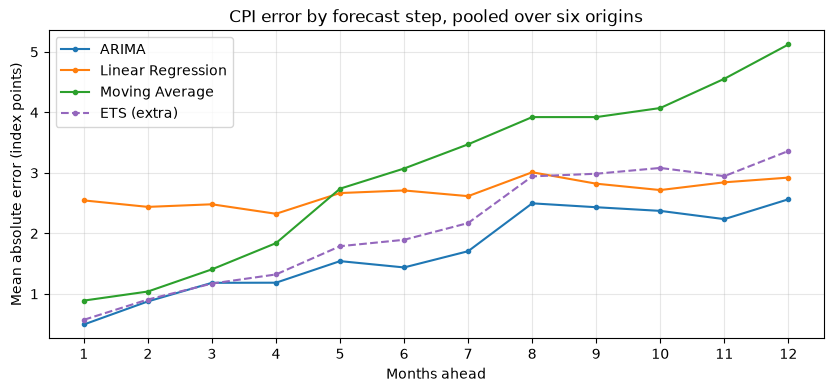

model,ARIMA,Linear Regression,Moving Average,ETS
months ahead,,,,
1,0.494,2.545,0.889,0.571
2,0.875,2.438,1.039,0.907
3*,1.183,2.481,1.406,1.170
4,1.185,2.324,1.839,1.321
5,1.541,2.667,2.739,1.788
6*,1.437,2.710,3.072,1.894
7,1.705,2.615,3.472,2.171
8,2.497,3.010,3.922,2.942
9,2.432,2.821,3.922,2.986


In [12]:
by_step = ev.error_by_step(pooled)[MODEL_ORDER]

fig, ax = plt.subplots(figsize=(10, 4))
for model in MODEL_ORDER:
    ax.plot(by_step.index, by_step[model], marker="o", markersize=3, color=COLORS[model],
            linestyle="--" if model in config.EXTRA_MODELS else "-",
            label=model + (" (extra)" if model in config.EXTRA_MODELS else ""))
ax.set_xlabel("Months ahead")
ax.set_ylabel("Mean absolute error (index points)")
ax.set_title("CPI error by forecast step, pooled over six origins")
ax.set_xticks(range(1, config.HORIZON + 1))
ax.legend()
save(fig, "16_error_by_step")
plt.show()

# Dashboard horizons (3, 6, 12 months) are marked with *.
table = by_step.copy()
table.index = [f"{h}*" if h in config.DASHBOARD_HORIZONS else str(h) for h in table.index]
table.rename_axis("months ahead")

## 8. Final forecast (preview)

The selected model is refit on all 104 months (Jan 2018 – Aug 2026) with the same tuning procedure, and forecasts Sep 2026 – Aug 2027. Inflation and purchasing power are derived from it. Saving these for the dashboard is task 5.

In [13]:
final_results, final_predictions = ev.forecast_from(cpi, config.DATA_END, models=[final_model])
final = final_results[final_model]
print(f"{final_model} settings on all data: {final.params}")

final_table = derive_all(cpi, final.forecast)
final_table["cpi_lower"], final_table["cpi_upper"] = final.lower, final.upper
final_table.round(2)

ARIMA settings on all data: {'order': (0, 1, 1), 'seasonal_order': (0, 0, 0, 0), 'aic': np.float64(179.1990449090025), 'drift_per_month': 0.3830893366197122}


,cpi,inflation,purchasing_power,cpi_lower,cpi_upper
2026-09-01,136.950,6.600,0.730,135.850,138.050
2026-10-01,137.330,6.800,0.730,135.510,139.160
2026-11-01,137.710,6.800,0.730,135.380,140.050
2026-12-01,138.100,6.200,0.720,135.340,140.850
2027-01-01,138.480,5.700,0.720,135.360,141.600
2027-02-01,138.860,5.800,0.720,135.420,142.310
2027-03-01,139.250,4.700,0.720,135.510,142.990
2027-04-01,139.630,2.300,0.720,135.620,143.640
2027-05-01,140.010,3.100,0.710,135.740,144.280
2027-06-01,140.400,3.600,0.710,135.880,144.910


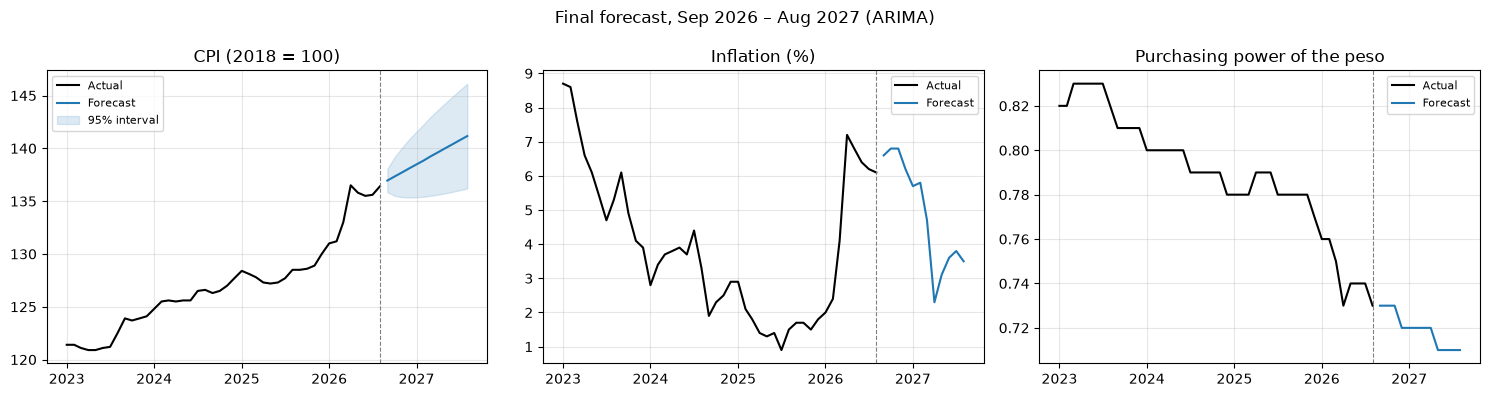

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
history_start = "2023-01"

axes[0].plot(cpi[history_start:], color="black", label="Actual")
axes[0].plot(final.forecast, color=COLORS[final_model], label="Forecast")
axes[0].fill_between(final.forecast.index, final.lower, final.upper, color=COLORS[final_model], alpha=0.15, label="95% interval")
axes[0].set_title("CPI (2018 = 100)")

axes[1].plot(actuals["inflation"][history_start:], color="black", label="Actual")
axes[1].plot(final_table["inflation"], color=COLORS[final_model], label="Forecast")
axes[1].set_title("Inflation (%)")

axes[2].plot(actuals["purchasing_power"][history_start:], color="black", label="Actual")
axes[2].plot(final_table["purchasing_power"], color=COLORS[final_model], label="Forecast")
axes[2].set_title("Purchasing power of the peso")

for ax in axes:
    ax.axvline(config.DATA_END, color="grey", linestyle="--", linewidth=0.8)
    ax.legend(fontsize=8)
fig.suptitle(f"Final forecast, Sep 2026 – Aug 2027 ({final_model})")
fig.tight_layout()
save(fig, "17_final_forecast")
plt.show()

## 9. Notes

*Draft observations from the outputs above. Review them, and rewrite them in your own words, before using them in the documentation.*

**Main test (Sep 2025 – Aug 2026).**
- Over the full test period Linear Regression has the lowest CPI error (RMSE 1.93), followed by ARIMA (2.54), ETS (3.42), and Moving Average (5.67).
- Before the price shock (Sep 2025 – Feb 2026) ARIMA is clearly the most accurate (RMSE 0.59), ahead of ETS (0.80), Linear Regression (1.58), and Moving Average (2.17).
- After the shock (Mar – Aug 2026) every model is too low, and Linear Regression is the least wrong (RMSE 2.24 vs. ARIMA 3.54).
- Linear Regression's forecasts were too high by 1.49 points on average before the shock. The March–April 2026 jump lifted actual CPI up to its trend line, which is why it wins the full test period. Its lead comes from the shock, not from tracking CPI more closely.

**Rolling origin and pooled evaluation.**
- Across the six origins, ARIMA ranks first three times (Aug 2022, Feb 2023, Aug 2023) and Linear Regression three times (Feb 2024, Aug 2024, Aug 2025). Linear Regression has done well recently, but poorly earlier, especially from Aug 2022 (RMSE 5.26).
- Averaged over the five folds, ARIMA has the lowest CPI error (RMSE 1.83) and Linear Regression the highest of the proposal models (2.96).
- Pooled over all six origins (72 months per model), ARIMA has the lowest CPI error on all three metrics: MAE 1.71, RMSE 2.01, MAPE 1.36%, against Linear Regression's 2.67, 3.14, and 2.16%.

**Selection.**
- On the pooled evaluation, **ARIMA** is selected: it has the lowest MAE, RMSE, and MAPE for CPI. It is also the most accurate for derived inflation and purchasing power, so the choice would be the same for all three variables. Including ETS does not change the result.
- On the main test alone, Linear Regression would have been selected. The selection basis was changed from the main test to the pooled evaluation after the results were seen; this must be stated in the paper together with both results.

**Error by forecast step (pooled).**
- ARIMA's error grows from 0.49 one month ahead to 2.56 twelve months ahead. At the dashboard horizons its mean absolute error is 1.18 (3 months), 1.44 (6 months), and 2.56 (12 months).
- At 3 months ETS is essentially tied with ARIMA (1.17 vs. 1.18); at 6 and 12 months ARIMA is the most accurate.
- Linear Regression's error is about 2.5 points even one month ahead, because its line reflects the long-run trend rather than the latest CPI level.

**ETS (extra).** Pooled, ETS ranks second (CPI RMSE 2.61), between ARIMA and Linear Regression. It was the best model at one origin (Aug 2023, RMSE 0.50). It does not beat ARIMA overall, so adding it would not change the final model.

**Final forecast (Sep 2026 – Aug 2027).**
- Refitting on all 104 months with the same tuning procedure gives ARIMA(0, 1, 1) with a drift of 0.383 points per month. The order differs from the test-origin model, ARIMA(1, 1, 0), because the tuning is repeated on the longer data; the two were within 0.1 AIC points of each other at the test origin.
- CPI is forecast to rise from 136.4 (Aug 2026) to about 141.2 by Aug 2027, with a 95% interval of 136.2–146.1 at 12 months.
- Derived inflation stays around 6–7% until early 2027, then falls to 2.3% in April 2027. This drop is a base effect: from April 2027 onwards, prices are compared with the already-high April 2026 level. Purchasing power is forecast to fall from 0.73 to 0.71.

**Caution on inflation MAPE.** Inflation's MAPE is 24–98% across models and periods because actual inflation was as low as 0.9–1.5% in some months; it should be read alongside MAE and RMSE, which are in percentage points.